# Example 5: Operational Short-Range Forecasting vs. NWM (Experiment 5)

Mirrors the paper's Experiment 5: short-range (1-18 h) operational forecasting, compared directly
against the National Water Model (NWM). The paper feeds HydroORBIT real NWM *meteorological*
forecast forcing (not observed/perfect-foresight); this lightweight example instead uses observed
future forcing as a stand-in, since raw NWM meteorological forecast fields are not bundled here.
HydroORBIT's forecast is compared against the real archived NWM *streamflow* forecast
(`*_NWM_forecast.csv`) and against observations.

**Case study**: basin `04045500` (Tahquamenon River near Paradise, MI) -- selected as the
highest-median-NSE basin with full lead-time coverage in the paper's Experiment 5 evaluation. This
notebook runs 30 forecast cycles spread across the 2025 evaluation year and reports NSE **at each
lead time**, pooled across those 30 cycles, for both HydroORBIT and NWM.

Data: `data/exp5_operational_nwm/04045500.csv` (hourly forcing + streamflow, 2024-2025) and
`04045500_NWM_forecast.csv` (NWM's own 1-18 h streamflow forecast, one row per issue time, 2025).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import HydroORBITPipeline

WEIGHTS_DIR = REPO_ROOT / "weights"
pipe = HydroORBITPipeline.from_pretrained(str(WEIGHTS_DIR))
print("Loaded HydroORBIT on device:", pipe.device)

FORCING_COLS = ["Tair", "Qair", "PSurf", "Wind_E", "Wind_N", "LWdown",
                "CRainf_frac", "CAPE", "PotEvap", "Rainf", "SWdown"]

def nse(obs, sim, min_samples=24):
    """Nash-Sutcliffe efficiency, pooled across whatever (obs, sim) pairs are given.
    Returns NaN below min_samples or when the observed variance is degenerate
    (near-constant obs), matching the guard used for the paper's own metrics."""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < min_samples:
        return np.nan
    den = np.sum((obs - obs.mean()) ** 2)
    scale = max(abs(obs.mean()), 1.0)
    if den <= (1e-10 * scale) ** 2 * len(obs):
        return np.nan
    return 1.0 - np.sum((sim - obs) ** 2) / den


def origins_for_eval_year(index, year, context_len, horizon):
    """Positions in `index` that fall within `year` and have enough trailing
    context (context_len) and enough remaining data (horizon) around them."""
    positions = np.where(index.year == year)[0]
    positions = positions[(positions >= context_len) & (positions + horizon <= len(index))]
    return positions


Loaded HydroORBIT on device: mps


In [2]:
BASIN = "04045500"
CONTEXT_LEN = 8760
HORIZON = 18       # hours -- matches NWM's short-range forecast length
N_ORIGINS = 50       # forecast cycles spread across the 2025 evaluation year -- this
                      # basin's real record has ~21% missing hours, so extra origins keep
                      # the per-lead sample count safely above the min-sample floor
EVAL_YEAR = 2025

obs = pd.read_csv(f"data/exp5_operational_nwm/{BASIN}.csv", index_col="datetime", parse_dates=True)
nwm = pd.read_csv(f"data/exp5_operational_nwm/{BASIN}_NWM_forecast.csv",
                   index_col="issue_time", parse_dates=True)
print("Observations:", obs.shape, obs.index.min(), "->", obs.index.max())
print("NWM forecasts:", nwm.shape, nwm.index.min(), "->", nwm.index.max())


Observations: (17544, 12) 2024-01-01 00:00:00 -> 2025-12-31 23:00:00
NWM forecasts: (8736, 18) 2025-01-02 00:00:00 -> 2025-12-31 23:00:00


In [3]:
# Issue times must (a) exist in the NWM archive, (b) have enough trailing obs context, and
# (c) have enough remaining obs to verify against -- see origins_for_eval_year for (b)/(c).
def _is_valid(t):
    if t not in obs.index:
        return False
    origin = obs.index.get_loc(t)
    return origin >= CONTEXT_LEN and origin + HORIZON <= len(obs)

nwm_year = nwm[nwm.index.year == EVAL_YEAR]
valid_times = nwm_year.index[nwm_year.index.map(_is_valid)]
issue_times = valid_times[np.linspace(0, len(valid_times) - 1, N_ORIGINS).astype(int)]

runs = []
for issue_time in issue_times:
    origin = obs.index.get_loc(issue_time)
    ctx_slice = obs.iloc[origin - CONTEXT_LEN:origin]
    fut_slice = obs.iloc[origin:origin + HORIZON]   # used only for observed forcing + verification here

    target = ctx_slice["Streamflow"].to_numpy(np.float32)
    forcing = ctx_slice[FORCING_COLS].to_numpy(np.float32)
    future_forcing = fut_slice[FORCING_COLS].to_numpy(np.float32)   # stand-in for NWM forecast forcing
    observed_future = fut_slice["Streamflow"].to_numpy(np.float32)

    out = pipe.predict(target, forcing=forcing, future_forcing=future_forcing, prediction_length=HORIZON)
    hydroorbit_median = out.median[0].numpy()
    nwm_forecast = nwm.loc[issue_time].to_numpy(dtype=float)

    runs.append({
        "issue_time": issue_time, "observed": observed_future,
        "hydroorbit": hydroorbit_median, "nwm": nwm_forecast,
    })
print(f"Ran {len(runs)} forecast cycles across {EVAL_YEAR}.")


Ran 50 forecast cycles across 2025.


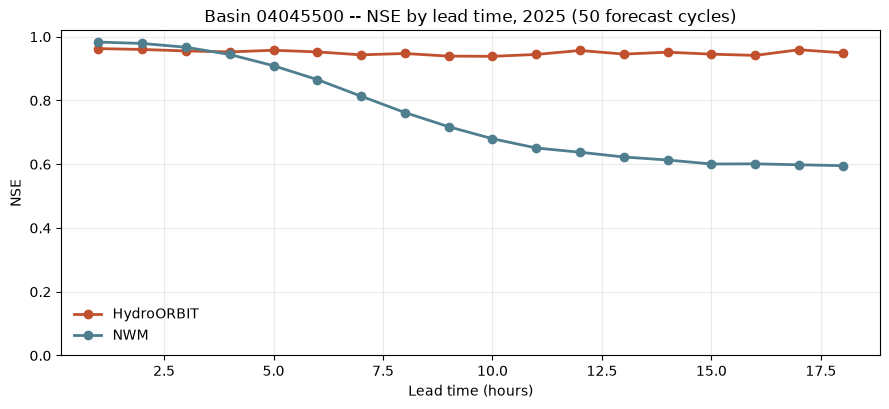

Median NSE  HydroORBIT: 0.950   NWM: 0.699


In [4]:
obs_stack = np.stack([r["observed"] for r in runs])
hydroorbit_stack = np.stack([r["hydroorbit"] for r in runs])
nwm_stack = np.stack([r["nwm"] for r in runs])
lead_h = np.arange(1, HORIZON + 1)
nse_hydroorbit = np.array([nse(obs_stack[:, h], hydroorbit_stack[:, h]) for h in range(HORIZON)])
nse_nwm = np.array([nse(obs_stack[:, h], nwm_stack[:, h]) for h in range(HORIZON)])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(lead_h, nse_hydroorbit, color="#C1502E", linewidth=2.0, marker="o", label="HydroORBIT")
ax.plot(lead_h, nse_nwm, color="#4F7F8F", linewidth=2.0, marker="o", label="NWM")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Lead time (hours)")
ax.set_ylabel("NSE")
ax.set_title(f"Basin {BASIN} -- NSE by lead time, {EVAL_YEAR} ({N_ORIGINS} forecast cycles)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Median NSE  HydroORBIT: {np.nanmedian(nse_hydroorbit):.3f}   NWM: {np.nanmedian(nse_nwm):.3f}")
